# Credit Risk ML system

## 1. Load the data
- We will bring in the loan applicant data.
- This data has details like income, age, and loan amount.
- It also tells us who repaid and who defaulted.

In [1]:
# importing the libraries -- 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv("credit_risk_dataset.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## 2. Exploratory Data Analysis (EDA) 
- Here we simply look at the data before touching it.
- We want to understand it first, then work on it.

### Basic info about the data
- Checking how many rows and columns we have.
- Checking the data type of each column.

In [3]:
df.shape

(32581, 12)

In [4]:
df.info()
print()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB



### Missing values
- Find out which columns have empty or missing values.
- This tells us where we may need to fix things later.

In [5]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

### Target balance

In [6]:
values = df['loan_status'].value_counts()
values

loan_status
0    25473
1     7108
Name: count, dtype: int64

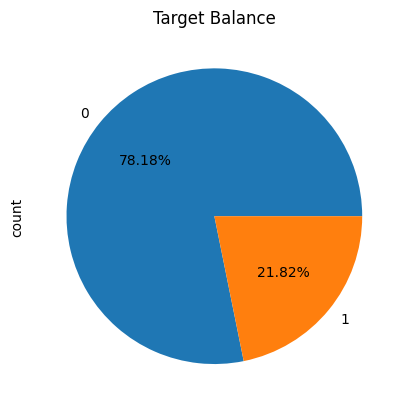

In [7]:
# means our target colm is unbalance 

values.plot(kind='pie',autopct='%1.2f%%')
plt.title('Target Balance')
plt.show()

### Outlier Check

In [8]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [9]:
numerical_col = df.select_dtypes(include='number')
numerical_col.columns

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_cred_hist_length'],
      dtype='object')

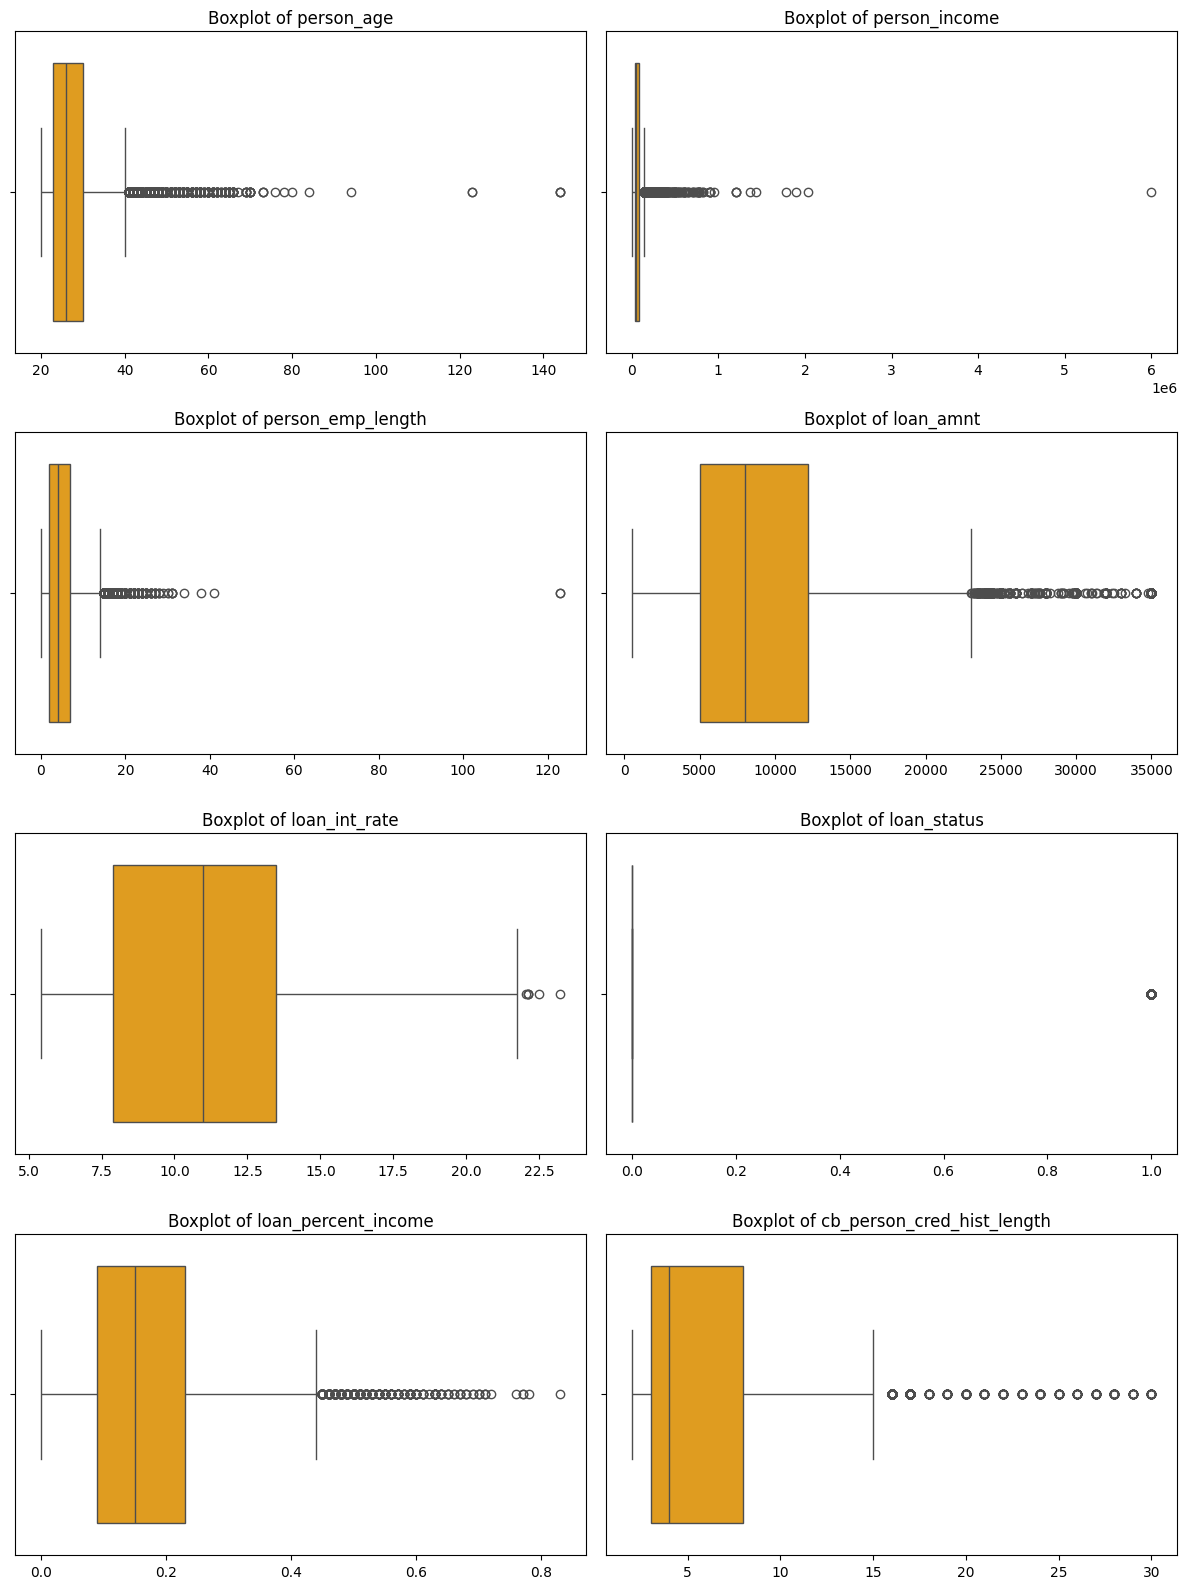

In [10]:
fig , axes = plt.subplots(4,2,figsize=(12,16))
axes = axes.flatten()     #flatten to easily loop through 1d array

for i , colm in enumerate(numerical_col):
    sns.boxplot(x=df[colm],ax=axes[i],color='orange')
    axes[i].set_title(f'Boxplot of {colm}')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()
    

### Correlation Check

<Axes: >

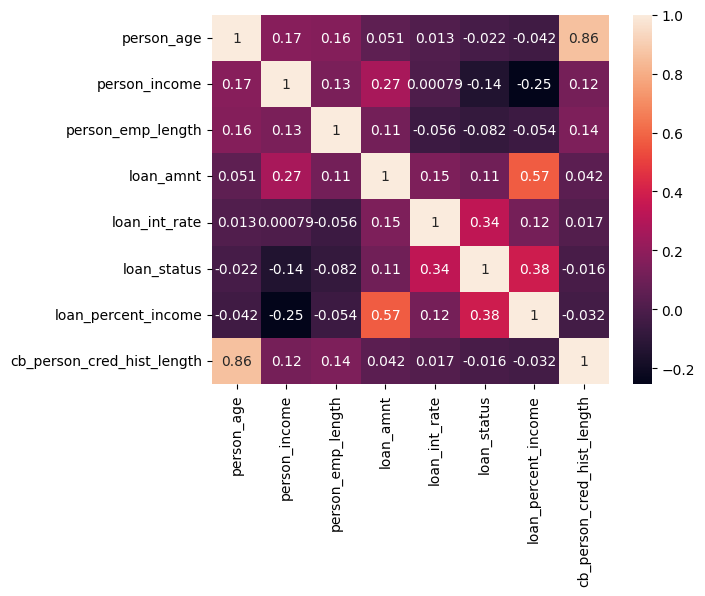

In [11]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr,annot=True)

## 3. Data Validation & Outlier Handling 

In [12]:
# handling duplicate values -- 

df_copy = df.copy()
print(f"Original Rows : {df_copy.shape[0]}")
df_copy.drop_duplicates(inplace=True)
print(f"Rows after removing duplicates : {df_copy.shape[0]}")

Original Rows : 32581
Rows after removing duplicates : 32416


In [13]:
# Removing ages below 18 and greater than 100 
df_copy = df_copy[(df_copy['person_age']>=18) & (df_copy['person_age']<=100)]
df_copy.shape[0]

# means 5 ages(outliers) removed 

32411

In [14]:
# Remove employment length greater than age or extreme outliers (>60)
df_copy = df_copy[df_copy['person_emp_length'] <= df_copy['person_age']]
df_copy = df_copy[df_copy['person_emp_length']<=60]

df_copy.shape[0]

31522

## 4. Features, Target & Train-Test Split

In [15]:
X = df_copy.drop('loan_status',axis=1)
y = df_copy['loan_status']

In [16]:
from sklearn.model_selection import train_test_split

X_train , X_test, y_train , y_test = train_test_split(X,y,random_state=42,test_size=0.2, stratify=y) 
#stratify -- to divide y equally in train and test

In [17]:
numeric_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
                     'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

## 5. Handle Class Imbalance

In [18]:
# 0 -> no loan (most) (neg)
# 1 -> yes loan (pos)

neg , pos = np.bincount(y_train)
scale_pos_w = neg/pos 

scale_pos_w

np.float64(3.6312213039485766)

## 6. Data Preprocessing — Pipelines & Column Transformer

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler , OneHotEncoder

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

### Preprocessing for Logistic Regression

In [21]:
# Logistic regression : impute + scale numeric , impute + ohe

preprocessor_lr = ColumnTransformer(
    transformers=[
        #Pipeline-for numerical col 
        ('num',Pipeline([
            ('imputer',SimpleImputer(strategy='median')),
            ('scaler',StandardScaler())
        ]),numeric_cols), 

        #Pipeline for cat colm 
        ('cat',Pipeline([
            ('impute',SimpleImputer(strategy="constant", fill_value="Missing")),
            ('onehot',OneHotEncoder(handle_unknown='ignore'))
        ]),categorical_cols)
    ])

### Preprocessing for XGBoost

In [22]:
#XGBoost: Impute numeric only (No Scaling), impute + One - Hot Encoding 

preprocessor_xg = ColumnTransformer(
    transformers=[
        ('num',Pipeline([
            ('impute',SimpleImputer(strategy='median'))
        ]),numeric_cols), 

        ('cat',Pipeline([
            ('imputer',SimpleImputer(strategy="constant",fill_value='Missing')), 
            ('ohe',OneHotEncoder(handle_unknown='ignore'))
        ]),categorical_cols)
    ])

## 7. Evaluation Helper Function

In [32]:
from sklearn.metrics import accuracy_score , f1_score , recall_score, precision_score, confusion_matrix , classification_report , precision_recall_curve

In [33]:
def evaluate_model(model_name,model,x_test,y_test,threshold=None):
    y_pred_prob = model.predict_proba(x_test)[:,1]

    if threshold:
        y_pred = (y_pred_prob>threshold).astype(int)
    else:
        y_pred = model.predict(x_test)

    #metrics 
    accuracy = accuracy_score(y_pred,y_test)
    precision = precision_score(y_test, y_pred) 
    recall  = recall_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred) 
    
    conf_matrix   = confusion_matrix(y_test, y_pred)
    class_report  = classification_report(y_test, y_pred)

    print(f"{model_name} Metrics:")
    if threshold is not None: # Only print threshold if provided
        print(f"Used Threshold : {threshold:.2f}")
        
    print(f"Accuracy : {accuracy:.2f}")
    print(f"Precision : {precision:.2f}")
    print(f"Recall : {recall:.2f}")
    print(f"F1 : {f1:.2f}")
    print()
    print(f"{model_name} Classification Report:")
    print(class_report)

    #Plotting confusion matrix
    sns.heatmap(conf_matrix, annot=True, fmt="d")
    plt.title(f"{model_name} Confusion Matrix")
    plt.ylabel("Actual Values")
    plt.xlabel("Predicted Values")
    plt.show()

    #Plotting ROC-AUC curve
    precisions, recalls, threshold = precision_recall_curve(y_test, y_pred_prob)
    plt.plot(recalls, precisions)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{model_name} Precision-Recall Curve")
    plt.show()

## 8. Stratified Cross-Validation

In [27]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5,random_state=42,shuffle=True)
scoring = {'roc_auc':'roc_auc', 'accuracy':'accuracy', 'precision':'precision', 'recall':'recall', 'f1':'f1'}

In [24]:
# Logistic Regression 
lr_cv_pipeline = Pipeline([
    ('preprocessor',preprocessor_lr), 
    ('classifier',LogisticRegression(max_iter=1000,class_weight='balanced',random_state=42))
])

In [26]:
# Xgboost model 
xg_cv_pipeline = Pipeline([
    ('preprocessor',preprocessor_xg),
    ('classifier',XGBClassifier(n_estimator=300,
                                max_depth=5,
                                learning_rate=0.1,
                                scale_pos_weight = scale_pos_w,
                                random_state=42))
])

In [28]:
for cv_name , pipeline in [("Logistic Regression",lr_cv_pipeline),('XGBoost',xg_cv_pipeline)]: 

    cv_results = cross_validate(pipeline,X_train,y_train,cv=cv,scoring=scoring,n_jobs=-1)

    print(cv_name),
    print(f"ROC-AUC : {cv_results['test_roc_auc'].mean()}")
    print(f"Accuracy : {cv_results['test_accuracy'].mean()}")
    print(f"Precision : {cv_results['test_precision'].mean()}")
    print(f"Recall : {cv_results['test_recall'].mean()}")
    print(f"F1 : {cv_results['test_f1'].mean()}")
    print()

Logistic Regression
ROC-AUC : 0.8705112830525306
Accuracy : 0.8115949542892269
Precision : 0.5448226008889892
Recall : 0.7781450872359963
F1 : 0.6408013995933108

XGBoost
ROC-AUC : 0.9388000296700062
Accuracy : 0.9104966361456424
Precision : 0.7978050038979538
Recall : 0.7858585858585859
F1 : 0.7913675290846589



## 9. Baseline Model — Logistic Regression

In [29]:
baseline_model = Pipeline([
    ('preprocessor',preprocessor_lr),
    ('classifier',LogisticRegression(class_weight='balanced'))
])

baseline_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

logistic_regression Metrics:
Accuracy : 0.82
Precision : 0.56
Recall : 0.79
F1 : 0.65

logistic_regression Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      4943
           1       0.56      0.79      0.65      1362

    accuracy                           0.82      6305
   macro avg       0.75      0.81      0.77      6305
weighted avg       0.85      0.82      0.83      6305



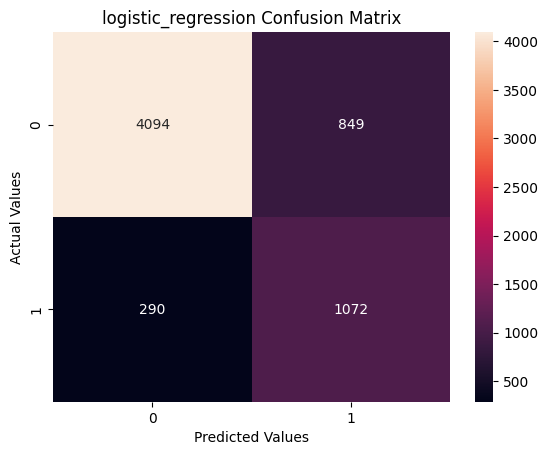

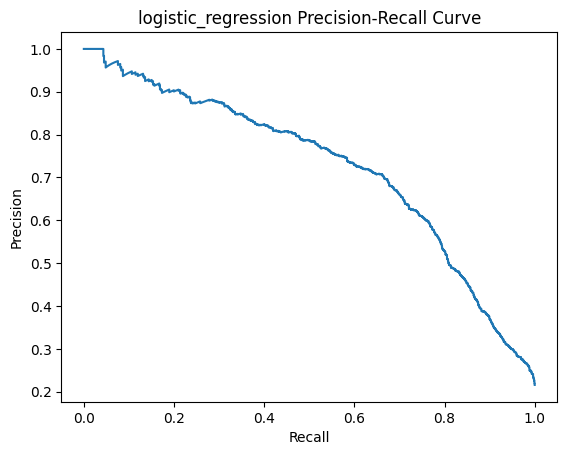

In [36]:
evaluate_model('logistic_regression',baseline_model,X_test,y_test)

## 10. XGBoost Hyperparameter Tuning

In [30]:
xg_model = Pipeline([
    ('preprocessor',preprocessor_xg), 
    ('classifier',XGBClassifier(learning_rate=0.1,scale_pos_weight=scale_pos_w,random_state=42))
])

xg_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [35]:
# Hyperparameter tuning 
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

param_grid = {
    "classifier__n_estimator": randint(150,600), 
    "classifier__max_depth": randint(3,9), 
    "classifier__learning_rate": uniform(0.01,0.5), 
    "classifier__subsample": uniform(0.6,0.4), #row sampling
    "classifier__gamma": uniform(0,5)   #high gamma - low risk of overfitting(simpler tree) , low gamma-high risk of overfitting(complex tree)
}


random_search = RandomizedSearchCV(
    xg_model,
    param_grid,
    n_iter=100, 
    cv = cv, 
    scoring='average_precision', 
    n_jobs =-1 
)


random_search.fit(X_train,y_train)

C:\Users\gokup\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:200: UserWarning: [07:18:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__gamma': <scipy.stats....00283D8D4BB90>, 'classifier__learning_rate': <scipy.stats....00283D8D6D850>, 'classifier__max_depth': <scipy.stats....00283D8D6D820>, 'classifier__n_estimator': <scipy.stats....00283D4026BD0>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits wil

In [38]:
random_search.best_params_

{'classifier__gamma': np.float64(0.505741073352382),
 'classifier__learning_rate': np.float64(0.23540814874475235),
 'classifier__max_depth': 7,
 'classifier__n_estimator': 393,
 'classifier__subsample': np.float64(0.9127488428722785)}

In [39]:
random_search.best_score_

np.float64(0.9004038062042623)

xgboost_optimized Metrics:
Accuracy : 0.93
Precision : 0.85
Recall : 0.80
F1 : 0.82

xgboost_optimized Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      4943
           1       0.85      0.80      0.82      1362

    accuracy                           0.93      6305
   macro avg       0.90      0.88      0.89      6305
weighted avg       0.92      0.93      0.92      6305



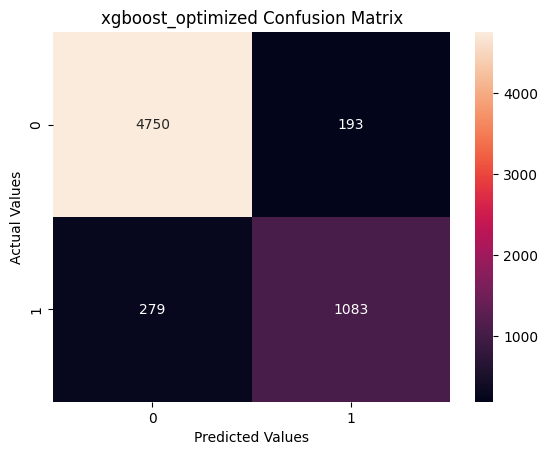

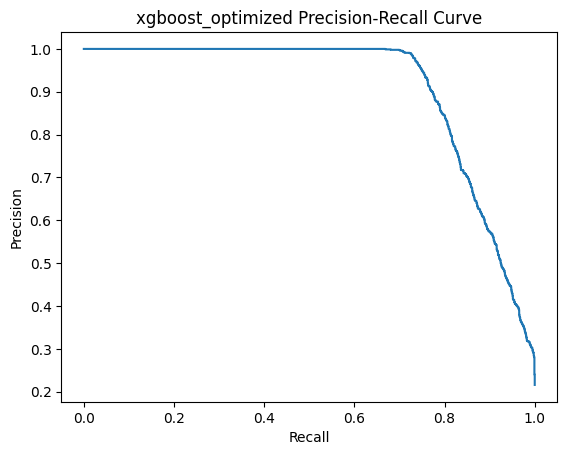

In [63]:
evaluate_model('xgboost_optimized',random_search,X_test,y_test)

## 11. Probability Calibration

In [43]:
# calibrated xgboost model 
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

best_model = random_search.best_estimator_

calibrated_model = CalibratedClassifierCV(
    best_model,cv=5,method='sigmoid'
)

calibrated_model.fit(X_train,y_train)

C:\Users\gokup\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:200: UserWarning: [13:46:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\gokup\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:200: UserWarning: [13:46:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\gokup\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:200: UserWarning: [13:46:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\gokup\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:200: UserWarning: [13:46:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameter

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2","Pipeline(step...=None, ...))])"
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the col

In [44]:
# get probabilities 
uncalibrated = xg_model.predict_proba(X_test)[:,1]
calibrated = calibrated_model.predict_proba(X_test)[:,1]

In [45]:
# create calibration curves
actual_uncal, predicted_uncal = calibration_curve(y_test, uncalibrated, n_bins=10)
actual_cal, predicted_cal  = calibration_curve(y_test, calibrated, n_bins=10)

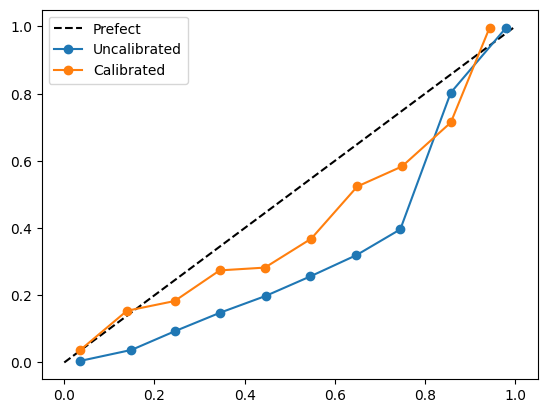

In [46]:
#plot
plt.plot([0,1], [0,1], 'k--', label="Prefect")
plt.plot(
    predicted_uncal,
    actual_uncal,
    "o-",
    label = "Uncalibrated"
)

plt.plot(
    predicted_cal,
    actual_cal,
    "o-",
    label = "Calibrated"
)
plt.legend()

### Optimizing the Classification Threshold

fianl_model Metrics:
Used Threshold : 0.57
Accuracy : 0.94
Precision : 0.95
Recall : 0.76
F1 : 0.84

fianl_model Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.96      4943
           1       0.95      0.76      0.84      1362

    accuracy                           0.94      6305
   macro avg       0.94      0.87      0.90      6305
weighted avg       0.94      0.94      0.94      6305



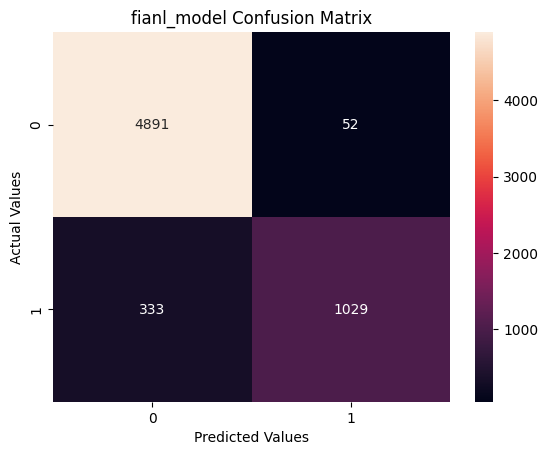

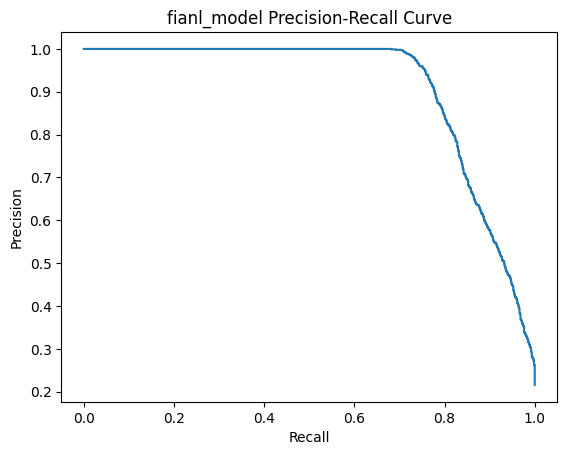

In [61]:
#Get the prob. of class 1 from XGBoost 
prob =  calibrated_model.predict_proba(X_test)[:,1]

#For each threshold calculate Precision and Recall 
precisions , recalls , thresholds = precision_recall_curve(y_test,prob) 

#Calculate F1 score for each threshold 
f1 = 2*(precisions*recalls)/(precisions+recalls+1e-9)

#Get the threshold that produces the highest f1-score
best = np.argmax(f1[:-1])
best_threshold = thresholds[best]

evaluate_model('fianl_model',calibrated_model,X_test,y_test,best_threshold)

## 12. SHAP Interpretation — Global

In [48]:
import shap

#Get Trained XGBoost classifier model out of the pipeline
xgb_classifier = xg_model.named_steps['classifier']

#Transform X_test using the same preprocessing used for training
x_test_transformed = xg_model.named_steps['preprocessor'].transform(X_test)

#Get feature names after one-hot enocding , so plots are readable
features = xg_model.named_steps['preprocessor'].get_feature_names_out()

#Convert to a dataframe for cleaner SHAP plots
x_test_df = pd.DataFrame(x_test_transformed,columns=features)

#Create SHAP explainer built for tree-based model
explainer = shap.TreeExplainer(xgb_classifier)

#Calculate SHAP values for every row in the test set
shap_values = explainer.shap_values(x_test_df)

### Global explaination 

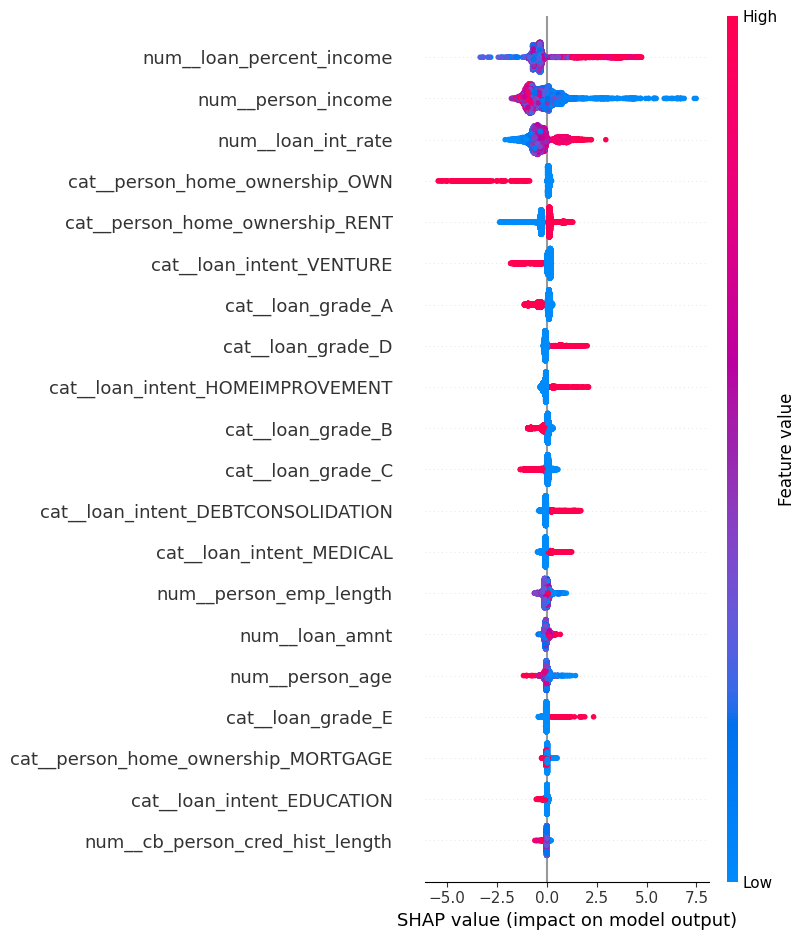

In [50]:
shap.summary_plot(shap_values,x_test_df)

## 13. Analyzing False Positives & False Negatives 

In [53]:
#Get predictions from the best performing XGBoost model on the test set 
y_pred = random_search.predict(X_test)

#Create a dataframe to easily compare the actual and predicted values
result_df = X_test.copy()
result_df['actual'] = y_test
result_df['predicted'] = y_pred

In [55]:
#Identify False Positive : Model Predicted 1, but the actual was 0 
false_pos = result_df[(result_df['actual']==0)& (result_df['predicted']==1)]

#Identify False Negative : Model Predicted 0, but the actual was 1
false_neg = result_df[(result_df['actual']== 1) & (result_df['predicted']== 0)]

print(f"False Positive : {len(false_pos)}")
print(f"False Negative : {len(false_neg)}")

False Positive : 193
False Negative : 279


In [ ]:
#False Negative > False Positive

## 14.Save the model 

In [64]:
## Save the model 
import joblib
joblib.dump(calibrated_model, "credit_risk_model.pkl")

['credit_risk_model.pkl']

In [62]:
joblib.dump(best_threshold, "best_threshold.pkl")

['best_threshold.pkl']